<a href="https://colab.research.google.com/github/tamaravdd/iese-dsmba/blob/main/notebooks/06_Merging_Timeseries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Session 6 · Time Series Data
## Bitcoin Price Analysis — Reading the Market Story

**Session objectives**
1. Merge pandas dataframes
2. Work with `DatetimeIndex` to slice and filter by date
3. Compute returns, apply resampling and rolling windows
---


In [1]:
# loading the libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')

---
## Part 0 — Merging Datasets (Quick Primer)

Before we dive into Bitcoin's price history, let's cover a skill you'll use in almost every data project: **combining two or more datasets into one**.

A single dataset rarely tells the whole story. Later in this notebook (BONUS section) we'll combine Bitcoin's price series with Apple's and Microsoft's to compare them. The tool for that is `pd.merge()` — for tables that share a common column — and its cousin `.join()`, for tables that share an index (handy for time series).

### How `pd.merge()` works

![Merge](https://raw.githubusercontent.com/tamaravdd/iese-dsmba/main/resources/join-types-python-merge-programming.png)



```python
result = left_df.merge(right_df, on='key_column', how='left')
```

- `on=` — which column(s) to match rows on
- `how=` — what to do when there's no match:
  - `'left'` — keep all rows from `left_df`, fill `NaN` if no match in `right_df`
  - `'inner'` — keep only rows that match in both
  - `'outer'` — keep all rows from both, fill `NaN` where there's no match

Let's practice with a small example: car models, their brands, and the parent group's profit margins.

In [ ]:
# Load a dataset of car models (brand, group, price, horsepower, etc.)
cars_df = pd.read_csv('https://raw.githubusercontent.com/ciri/iese-dsfb/main/resources/tabular/cars.csv')

print(f"Cars dataset: {cars_df.shape}")
cars_df.head(3)

> ✅ **Sanity check:** `cars_df` should have one row per car model, with columns including `brand`, `group`, `price`, and `total_max_power_hp`.

In [ ]:
# Step 1: aggregate to one row per brand
brand_stats = cars_df.groupby('brand').agg(
    avg_price   = ('price', 'mean'),
    avg_hp      = ('total_max_power_hp', 'mean'),
    model_count = ('model_name', 'count'),
).reset_index()

brand_stats.head()

In [ ]:
# Step 2: load a second dataset — profit margins, but at the GROUP level
# (e.g. Volkswagen Group includes Audi, Porsche, VW)
margins_df = pd.read_csv('https://raw.githubusercontent.com/ciri/iese-dsfb/main/resources/tabular/car_margins.csv')
margins_df

`brand_stats` is keyed by `brand`, but `margins_df` is keyed by `group`. To connect them, we need a lookup table that maps each brand to its group — we can build that directly from `cars_df`:

In [ ]:
# Step 3: build a brand -> group lookup, then chain two merges
brand_to_group = cars_df[['brand', 'group']].drop_duplicates()

merged = (
    brand_stats
    .merge(brand_to_group, on='brand', how='left')
    .merge(margins_df,     on='group', how='left')
)

print(f"Rows: {len(merged)}")
merged.sort_values('avg_price', ascending=False)

> ✅ **Sanity check:** `merged` should still have one row per brand (same as `brand_stats`) — a `merge` with `how='left'` never adds or drops rows from the left table, it only adds columns.

>✏️ **You try it**
>
> 1. Which `group` has the highest `oem_gross_margin`? Does it also sell the most expensive cars on average?
> 2. Re-run the last merge with `how='inner'` instead of `how='left'`. Does the row count change? Why or why not?
> 3. **Preview:** in the BONUS section we'll combine Bitcoin, Apple, and Microsoft price series using `.join()`. That's the same idea as `merge`, but matching on the **date index** instead of a column — keep this in mind when we get there.

<details>
<summary>Click to reveal solution</summary>

```python
# 1. highest-margin group, and its average price
(merged[['group', 'oem_gross_margin', 'avg_price']]
   .drop_duplicates('group')
   .sort_values('oem_gross_margin', ascending=False))

# 2. inner merge — row count drops if any brand's group is missing from margins_df
inner_merged = (
    brand_stats
    .merge(brand_to_group, on='brand', how='left')
    .merge(margins_df,     on='group', how='inner')
)
print(f"left: {len(merged)} rows -> inner: {len(inner_merged)} rows")
```
</details>

## Business Context

Bitcoin hit an all-time high after the U.S. election in November 2024. As a **risk analyst**, your job is to:

1. Quantify the typical volatility of Bitcoin over the past year
2. Calculate Value at Risk (VaR) and explain it to a non-technical stakeholder
3. Identify any day-of-week patterns in returns
4. Visualize the price trend with an annotated narrative

---

> 🧠 **Before running any code — write your hypotheses:**
> - Do you expect Bitcoin to be more or less volatile than the S&P 500?
> - Which days of the week do you expect to have the highest returns?
> - What major events do you think would show up in a 2024 price chart?

---
## Part 1 — Load & Index

### 1.1 Load the Bitcoin data

We will use Coinmarketcap to obtain the price series of Bitcoin over the past year. They have both an API or a website where you can download the data:

[https://coinmarketcap.com/currencies/bitcoin/historical-data/](https://coinmarketcap.com/currencies/bitcoin/historical-data/)

You can also download the corresponding bitcoin chart that I downloaded a year ago:

In [4]:
# local download
# df = pd.read_csv('./data_raw/BTC.csv', delimiter=';')

# google drive download
#from google.colab import drive
#drive.mount('/content/drive')
#df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/data_raw/BTC.csv", delimiter=';')

# quick fix: download from github url
df = pd.read_csv("https://raw.githubusercontent.com/tamaravdd/iese-dsmba/refs/heads/main/resources/BTC.csv", delimiter=';')

df.head()
df.info()
print(f'Loaded: {df.shape[0]} rows')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timeOpen   364 non-null    object 
 1   timeClose  364 non-null    object 
 2   timeHigh   364 non-null    object 
 3   timeLow    364 non-null    object 
 4   name       364 non-null    int64  
 5   open       364 non-null    float64
 6   high       364 non-null    float64
 7   low        364 non-null    float64
 8   close      364 non-null    float64
 9   volume     364 non-null    float64
 10  marketCap  364 non-null    float64
 11  timestamp  364 non-null    object 
dtypes: float64(6), int64(1), object(5)
memory usage: 34.3+ KB
Loaded: 364 rows


In [5]:
# select the columns we are interested in
df = df[['timestamp', 'open', 'high', 'low', 'close', 'volume']]

df.columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
print(f'New Loaded: {df.shape[0]} rows')
df.head(3)

New Loaded: 364 rows


,Date,Open,High,Low,Close,Volume
0,2025-04-22T23:59:59.999Z,87521.8712,93817.3838,87084.5294,93441.8933,55899038455.7300
1,2025-04-21T23:59:59.999Z,85171.5428,88460.0962,85143.8377,87518.9050,41396190189.8800
2,2025-04-20T23:59:59.999Z,85066.0689,85306.3813,83976.8458,85174.3016,14664050811.9300


> ✅ **Sanity check:** confirm that we did not lose any rows

### 1.2 Convert date and set as index

This is the crucial step that unlocks all time series functionality.

In [6]:
# Step 1: Convert string to datetime
# Dates are in ISO 8601 format (e.g., '2024-05-01T00:00:00.000Z')
# Ask an LLM when you're unsure of the format — paste a sample date
df['Date'] = pd.to_datetime(df['Date'], utc=True)

# Step 2: Set as index and sort
# since Date is the key identifier, it's appropriate to remove it
# from the columns and set it as index instead, we also sort by date
df = df.set_index('Date').sort_index()

> ✅ **Sanity check:**  Confirm the index row are dates and ordered correctly

In [7]:
df.index

DatetimeIndex(['2024-04-24 23:59:59.999000+00:00',
               '2024-04-25 23:59:59.999000+00:00',
               '2024-04-26 23:59:59.999000+00:00',
               '2024-04-27 23:59:59.999000+00:00',
               '2024-04-28 23:59:59.999000+00:00',
               '2024-04-29 23:59:59.999000+00:00',
               '2024-04-30 23:59:59.999000+00:00',
               '2024-05-01 23:59:59.999000+00:00',
               '2024-05-02 23:59:59.999000+00:00',
               '2024-05-03 23:59:59.999000+00:00',
               ...
               '2025-04-13 23:59:59.999000+00:00',
               '2025-04-14 23:59:59.999000+00:00',
               '2025-04-15 23:59:59.999000+00:00',
               '2025-04-16 23:59:59.999000+00:00',
               '2025-04-17 23:59:59.999000+00:00',
               '2025-04-18 23:59:59.999000+00:00',
               '2025-04-19 23:59:59.999000+00:00',
               '2025-04-20 23:59:59.999000+00:00',
               '2025-04-21 23:59:59.999000+00:00',
            

In [8]:
# Sanity check: what type is the index now?
print('Index type:', type(df.index))
print('First date:', df.index[0])
print('Last date: ', df.index[-1])
df.head(3)

Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
First date: 2024-04-24 23:59:59.999000+00:00
Last date:  2025-04-22 23:59:59.999000+00:00


,Open,High,Low,Close,Volume
Date,,,,,
2024-04-24 23:59:59.999000+00:00,66408.7221,67075.3696,63589.8719,64276.8974,30276655120.0200
2024-04-25 23:59:59.999000+00:00,64275.0210,65275.2075,62783.6333,64481.7066,32155786816.0100
2024-04-26 23:59:59.999000+00:00,64485.3699,64789.6575,63322.3996,63755.3213,24139372950.1500


> ✅ **Sanity check:** The index should say `DatetimeIndex`, not `RangeIndex` or `Index`. If it still shows `RangeIndex`, the `set_index` step failed — check that `Date` is the correct column name.

### 1.3 Explore and slice by date

In [9]:
df.info()  # note the DatetimeIndex and dtypes

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 364 entries, 2024-04-24 23:59:59.999000+00:00 to 2025-04-22 23:59:59.999000+00:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    364 non-null    float64
 1   High    364 non-null    float64
 2   Low     364 non-null    float64
 3   Close   364 non-null    float64
 4   Volume  364 non-null    float64
dtypes: float64(5)
memory usage: 17.1 KB


In [10]:
df.describe()

,Open,High,Low,Close,Volume
count,364.0000,364.0000,364.0000,364.0000,364.0000
mean,76790.7366,78316.3218,75256.4768,76864.6222,40032114489.8960
std,15708.8650,16035.0162,15348.8666,15722.4103,23604278538.5835
min,53949.0872,54838.1457,49121.2374,53948.7522,9858198792.6100
25%,63093.5709,64161.0409,62123.3230,63097.4136,25464619106.1575
50%,69310.8357,70221.5449,68511.5399,69351.0765,32980233977.0450
75%,93685.4447,95218.5892,91433.6796,93688.8864,47470136981.0750
max,106147.2953,109114.8848,105291.7379,106146.2630,149218945579.6500


In [11]:
# Slice by date — reads like a sentence
df.loc['2024-11-01':'2024-11-30'].describe()  # November 2024 — the post-election surge

,Open,High,Low,Close,Volume
count,30.0000,30.0000,30.0000,30.0000,30.0000
mean,85696.2170,88053.2606,84430.8647,86570.7080,68526962508.8323
std,10766.5016,10757.1279,10472.4889,10529.1989,29916551457.7022
min,67811.1743,69361.6580,66803.6500,67811.5091,18184612091.3200
25%,76066.1722,77020.5254,75680.0030,76603.8244,46122706729.4675
50%,90190.2635,91816.9829,87933.2833,90550.5596,67300553713.8100
75%,94022.8025,97183.4374,92426.8514,95324.2226,82155311493.4050
max,99006.7423,99655.5011,97232.8931,98997.6621,133673285374.5000


The structure of the index also helps to select the data in special ways. For instance, to select the Friday opening prices, you can apply the function `day_name` to the index:

In [12]:
# Filter by day of week
df[df.index.day_name() == 'Friday'].head(5)

,Open,High,Low,Close,Volume
Date,,,,,
2024-04-26 23:59:59.999000+00:00,64485.3699,64789.6575,63322.3996,63755.3213,24139372950.1500
2024-05-03 23:59:59.999000+00:00,59122.3009,63320.5034,58848.3121,62889.8367,33172023048.2000
2024-05-10 23:59:59.999000+00:00,63055.1910,63446.7425,60208.7815,60792.7768,27804954694.2200
2024-05-17 23:59:59.999000+00:00,65231.2987,67459.4595,65119.3150,67051.8749,28031279309.7200
2024-05-24 23:59:59.999000+00:00,67928.1303,69220.2939,66622.6687,68526.0978,29197308152.6200


Alternatively, you could use `df.index.month == 11`. To select the opening prices from a particular month:

In [13]:
# Filter by month
df[df.index.month == 11].head(5)  # November only

,Open,High,Low,Close,Volume
Date,,,,,
2024-11-01 23:59:59.999000+00:00,70216.8970,71559.0166,68779.7003,69482.4699,49989795365.0900
2024-11-02 23:59:59.999000+00:00,69486.0239,69867.3519,69033.7223,69289.2767,18184612091.3200
2024-11-03 23:59:59.999000+00:00,69296.3821,69361.6580,67482.5254,68741.1155,34868307655.1800
2024-11-04 23:59:59.999000+00:00,68742.1347,69433.1764,66803.6500,67811.5091,41184819348.3300
2024-11-05 23:59:59.999000+00:00,67811.1743,70522.7868,67458.8697,69359.5662,46046889204.1300


### 1.4 Plot the price with annotations

A price chart without context is just noise. We annotate key events to tell a story.

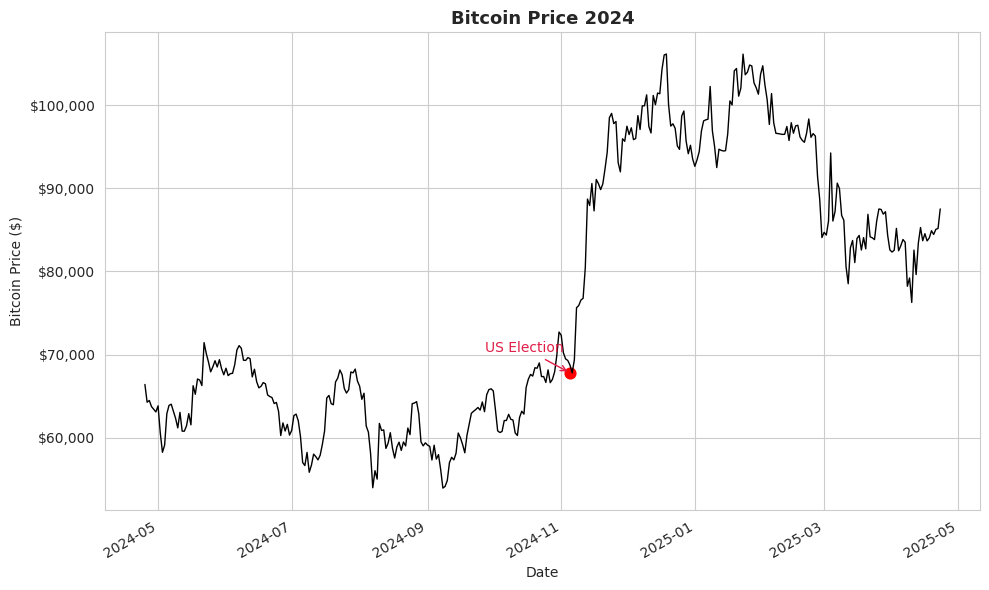

In [14]:
# Base plot (simple)
df['Open'].plot(figsize=(10, 6), color='black', linewidth=1, ylabel='Bitcoin Price ($)'
)

# Key date + value
election_date = pd.Timestamp('2024-11-05')
election_price = df.loc['2024-11-05', 'Open'].item()

# Highlight point
plt.scatter(election_date, election_price, color='r', s=60)

# Simple annotation
plt.annotate(
    "US Election",
    xy=(election_date, election_price),
    xytext=(pd.Timestamp('2024-10-15'), election_price + 2500),
    arrowprops=dict(arrowstyle='->', color='#E11D48'),
    color='#E11D48',
    ha='center'
)

# Formatting
plt.title('Bitcoin Price 2024', fontsize=13, weight='bold')
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}')
)


plt.tight_layout()
plt.show()

> 🧠 **Pause and Think:** Add one more annotation to the chart — pick a date where you see a notable move and explain what happened.

---
## Part 2 — Returns & Risk

### 2.1 Daily returns

Analysts work with **returns** (% change) rather than prices, because returns are comparable across assets and time periods.

In [ ]:
# Daily return = today's close / yesterday's close - 1
# pct_change() does this automatically — but data must be sorted first!
df_return = df['Close'].pct_change()

 >✅  Sanity check: the first return should be NaN (no previous day), check the first calculated values

In [ ]:
print('First few returns:')
print(df_return.head())
print(f'\nMean daily return: {df_return.mean():.4f} ({df_return.mean()*100:.2f}%)')
print(f'Daily std dev:     {df_return.std():.4f} ({df_return.std()*100:.2f}%)')

First few returns:
Date
2024-04-24 23:59:59.999000+00:00       NaN
2024-04-25 23:59:59.999000+00:00    0.0032
2024-04-26 23:59:59.999000+00:00   -0.0113
2024-04-27 23:59:59.999000+00:00   -0.0053
2024-04-28 23:59:59.999000+00:00   -0.0048
Name: Close, dtype: float64

Mean daily return: 0.0014 (0.14%)
Daily std dev:     0.0270 (2.70%)


The daily returns can be plotted in the same way as the prices:

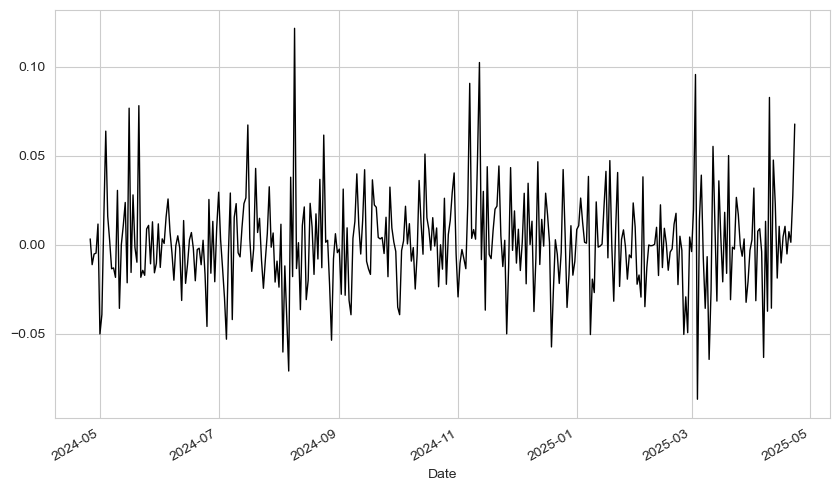

In [ ]:
df_return.plot(figsize=(10,6), color='black', linewidth=1);

>✅ **Sanity check:** Are there any returns > 50% or < -50%? If so, check whether those dates correspond to known events, or whether there's a data issue.

### 2.2 Value at Risk (VaR)

**VaR** answers: *What's the worst daily loss we should expect on 95% of trading days?*

Mathematically: the 5th percentile of the return distribution.

In [ ]:
confidence_level = 0.95
var_quantile     = 1 - confidence_level
var_value        = df_return.quantile(var_quantile)

print(f'95% VaR: {var_value:.4f} ({var_value*100:.2f}%)')
print()
print('How to read this:')
print(f'  On 95% of trading days, daily loss should not exceed {abs(var_value)*100:.1f}%.')
print(f'  On 1 in 20 days, however, we may lose more.')

95% VaR: -0.0391 (-3.91%)

How to read this:
  On 95% of trading days, daily loss should not exceed 3.9%.
  On 1 in 20 days, however, we may lose more.


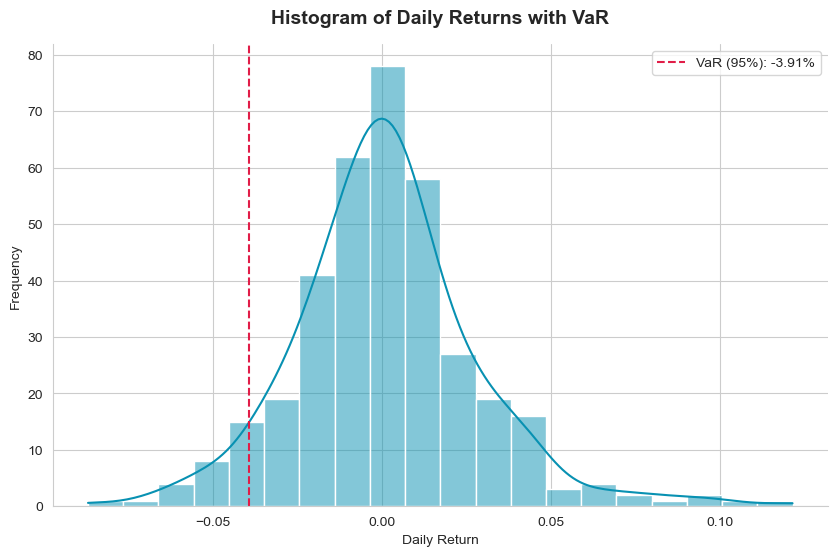

In [ ]:
# visualize it

plt.figure(figsize=(10, 6))
sns.histplot(df_return, bins=20, kde=True, color='#0891B2', edgecolor='white')
plt.axvline(var_value, color='#E11D48', linestyle='--', label=f'VaR ({int(confidence_level*100)}%): {var_value:.2%}')
plt.title('Histogram of Daily Returns with VaR', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.legend()
sns.despine()
plt.grid(True)
plt.show()


# ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))


**Weekly returns**

Weekly returns, based on the percentage change across Fridays, can be calculated after filtering out the rest of the days. Beware that this could be wrong for the weeks in which the Friday is not a trading day.

In [ ]:
df_w_return = df[df.index.day_name() == 'Friday']['Close'].pct_change()
df_w_return.head()

Date
2024-04-26 23:59:59.999000+00:00       NaN
2024-05-03 23:59:59.999000+00:00   -0.0136
2024-05-10 23:59:59.999000+00:00   -0.0333
2024-05-17 23:59:59.999000+00:00    0.1030
2024-05-24 23:59:59.999000+00:00    0.0220
Name: Close, dtype: float64

>✏️ **You try it**
> What is the median return (`pct_change`) on the different days of the week if always buy/sell at the High price?
>
>1. Create a new column where you store the day name
>2. Create another column to store the percentage change
>3. Group by the day column, and calculate the relevant statistic for the percentage change.
>4. Plot the result using `df.plot.bar()`

> 🤖 **AI prompting tip:** Ask Claude: *"How does this 95% VaR of [X]% compare to the S&P 500's typical daily VaR? What does that say about Bitcoin as an asset class?"*

---
## Part 3 — Patterns in Time

### 3.1 Day-of-week effect - this is the you try it above, can do together or they do it.

Does Bitcoin return more on certain days? (Unlike stock markets, crypto trades 24/7 — so every day matters.)

In [ ]:
# Add day of week to the returns series
df['daily_return'] = df['Close'].pct_change()
df['day_name'] = df.index.day_name()

# Group by day and compute median return
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_returns = (
    df.groupby('day_name')['daily_return']
    .agg(['median', 'mean', 'std'])
    .loc[day_order]
    .round(4)
)

print('Median return by day of week:')
print((day_returns * 100).round(3))

Median return by day of week:
           median    mean    std
day_name                        
Monday     0.2700  0.2600 3.4100
Tuesday   -0.2100 -0.0100 2.7700
Wednesday -0.3400  0.4400 3.1700
Thursday  -0.2100 -0.1300 2.6700
Friday     0.6600  0.5700 2.7000
Saturday   0.0500  0.1700 0.9400
Sunday    -0.2000 -0.3300 2.5900


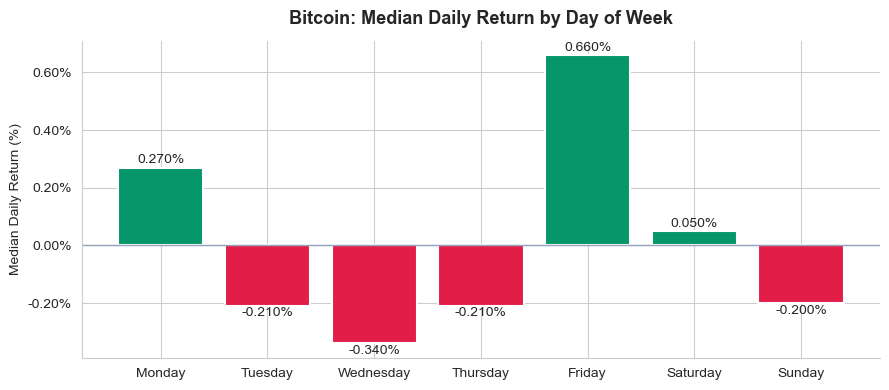

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#059669' if v >= 0 else '#E11D48' for v in day_returns['median']]

bars = ax.bar(day_returns.index, day_returns['median'] * 100,
              color=colors, edgecolor='white', linewidth=1.5)

ax.axhline(0, color='#94A3B8', linewidth=1)
ax.set_title('Bitcoin: Median Daily Return by Day of Week', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Median Daily Return (%)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}%'))

for bar, val in zip(bars, day_returns['median']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005 * (1 if val >= 0 else -1),
            f'{val*100:.3f}%', ha='center', va='bottom' if val >= 0 else 'top',
            fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

> 🔍 **Sanity check:** The differences between days are likely very small (fractions of a percent). If one day shows returns of +5% vs. -5% on other days, something is wrong — check whether that day has very few observations.

> **Interpretation:** Are these differences statistically meaningful, or just noise from ~52 Mondays in a year? With small samples, patterns can be illusory. This is a good moment to discuss the difference between *statistical* and *practical* significance.



### 3.2 Resampling: monthly view

Aggregating time series data by a new time period is often called **resampling**. The method `resample`, designed for Pandas data frames with a `Datetime` is driven by the index. In the following example, I apply this method to get the average weekly open price of Bitcoin.

In [ ]:
# Resample to monthly — each point is the average open price for that month
monthly_price = df['Open'].resample('ME').mean()

This can also be done by week `resample('W')`

 >✅ **Sanity check**: how many rows should we have?

In [ ]:
n_months = len(monthly_price)
print(f'Monthly rows: {n_months}  (expected: number of months in the dataset)')
monthly_price

Monthly rows: 13  (expected: number of months in the dataset)


Date
2024-04-30 00:00:00+00:00   64184.2002
2024-05-31 00:00:00+00:00   65044.2126
2024-06-30 00:00:00+00:00   66057.7892
2024-07-31 00:00:00+00:00   62737.7648
2024-08-31 00:00:00+00:00   60103.8967
Freq: ME, Name: Open, dtype: float64

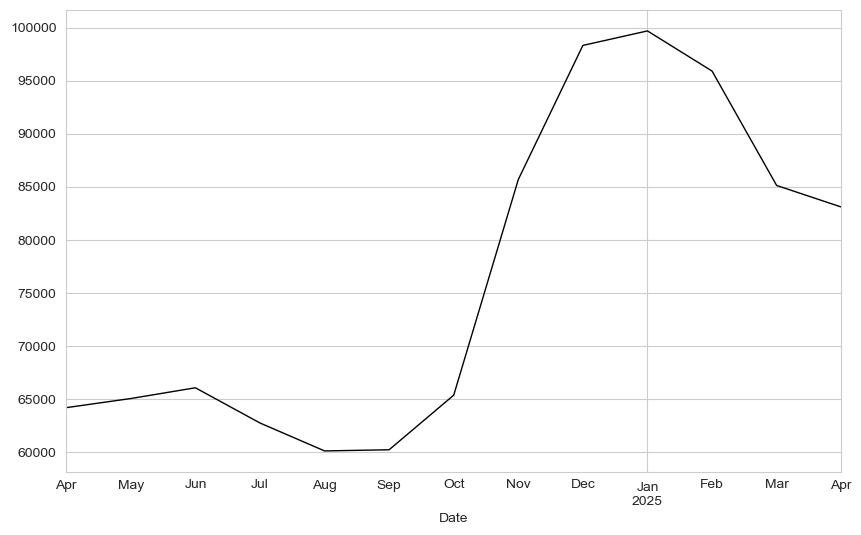

In [ ]:
# we can plot the monthly prices then
monthly_price.plot(figsize=(10,6), color='black', linewidth=1);

### 3.3 Rolling windows: extracting the trend

The logic of `rolling` is similar to that of `resampling`, but it groups the rows around every value of the index (except at the extremes). The set of these groups is called a **rolling window**. This is easily seen in the following calculation, which extracts a **moving average** (MA) trend for the opening prices (moving average is a popular name for the rolling mean).

In [ ]:
df['Open'].rolling(5).mean().head(10)

Date
2024-04-24 23:59:59.999000+00:00          NaN
2024-04-25 23:59:59.999000+00:00          NaN
2024-04-26 23:59:59.999000+00:00          NaN
2024-04-27 23:59:59.999000+00:00          NaN
2024-04-28 23:59:59.999000+00:00   64468.7234
2024-04-29 23:59:59.999000+00:00   63808.2518
2024-04-30 23:59:59.999000+00:00   63721.1316
2024-05-01 23:59:59.999000+00:00   62945.9572
2024-05-02 23:59:59.999000+00:00   61846.5001
2024-05-03 23:59:59.999000+00:00   60986.2575
Name: Open, dtype: float64

As a default, the terms included in the rolling window are collected leftwards. Here the length has been set to 5. So, the first 4 terms of the moving average are `NaN`'s. But you may prefer to center the window in the current observation. In that case, you will get 2 `NaN`'s at each extreme of the series. This is done with:

In [ ]:
ma = df['Open'].rolling(5, center=True).mean()
ma.head(10)

Date
2024-04-24 23:59:59.999000+00:00          NaN
2024-04-25 23:59:59.999000+00:00          NaN
2024-04-26 23:59:59.999000+00:00   64468.7234
2024-04-27 23:59:59.999000+00:00   63808.2518
2024-04-28 23:59:59.999000+00:00   63721.1316
2024-04-29 23:59:59.999000+00:00   62945.9572
2024-04-30 23:59:59.999000+00:00   61846.5001
2024-05-01 23:59:59.999000+00:00   60986.2575
2024-05-02 23:59:59.999000+00:00   60943.1908
2024-05-03 23:59:59.999000+00:00   60953.7978
Name: Open, dtype: float64

A moving average is frequently used to create a **nonparametric trend**, that is, a trend which is not given as a mathematical function of time, like a linear or quadratic trend. The chart below illustrates this. The dashed line corresponds to the actual prices, and the solid line to the MA trend.

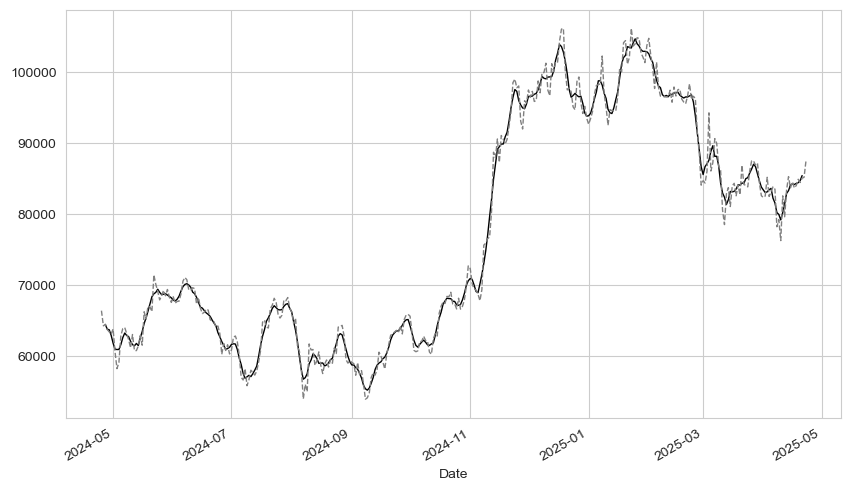

In [ ]:
ma.plot(figsize=(10,6), color='black', linewidth=1)
df['Open'].plot(color='gray', linestyle='--', linewidth=1);

> **Interpretation prompt:** When the short-term MA crosses above the long-term MA (a "golden cross"), traders often interpret this as a bullish signal. When does this happen in your chart? Does the price action afterward support the interpretation?

---
## BONUS — Stock Comparison

How does Bitcoin compare to traditional assets over the same period?

<div class='warning'>
This part is only for if we have enough time, though I highly recommend that you try it as it shows how to combine datasets.
</div>

## Microsoft v.s. Apple Analysis

We could do a similar analysis for more traditional stocks like Apple and Microsoft. For this, we'd need to download their respective datasets from [Yahoo Finance](https://finance.yahoo.com/quote/MSFT/history?period1=511056000&period2=1693353600&interval=1d&filter=history&frequency=1d&includeAdjustedClose=true) and load it in as usual. Yahoo has recently disabled this functionality from their website but you can either crawl it yourself or use packages that can help you for that.

Let's use  `yfinance` (installed using `! pip install yfinance`). If it doesn't work for you , you can download the time series from here: [MSFT](/www/resources/MSFT.csv), [AAPL](/www/resources/AAPL.csv), [NVDA](/www/resources/NVDA.csv).

In [ ]:
# Install yfinance if needed
# !pip install yfinance --quiet

In [ ]:
import yfinance as yf

# Download Apple and Microsoft data
start_date = df.index.min().strftime('%Y-%m-%d')
end_date   = df.index.max().strftime('%Y-%m-%d')

df_aapl = yf.download('AAPL', start=start_date, end=end_date, auto_adjust=True)
df_msft = yf.download('MSFT', start=start_date, end=end_date, auto_adjust=True)

df_aapl.columns = [col[0] for col in df_aapl.columns]
df_msft.columns = [col[0] for col in df_msft.columns]

print('AAPL rows:', len(df_aapl), '| MSFT rows:', len(df_msft))

ModuleNotFoundError: No module named 'yfinance'

---
## 🅰️ Your Turn — Part 1: Airbnb Price Seasonality

**`calendar.csv`** from Inside Airbnb has one row per listing per day (365 rows × N listings).
It's genuine time series data — price and availability for every future date.

> **Madrid calendar URL** (swap for your city):
> `https://data.insideairbnb.com/spain/comunidad-de-madrid/madrid/2024-09-13/data/calendar.csv.gz`

In [ ]:
# Load Airbnb calendar data
CAL_URL = "https://data.insideairbnb.com/spain/comunidad-de-madrid/madrid/2024-09-13/data/calendar.csv.gz"

cal = pd.read_csv(CAL_URL, parse_dates=['date'])
print(f"Shape: {cal.shape}")
print(cal.dtypes[['date', 'available', 'price']].to_string())
cal.head(3)

In [ ]:
# Clean price column (same '$1,234.00' format as listings.csv)
cal['price_usd'] = (
    cal['price']
    .str.replace(r'[\$,]', '', regex=True)
    .astype(float)
)

# Set date as index — this unlocks resample() and rolling()
cal = cal.set_index('date').sort_index()

# Sanity: date range and median price
print(f"Date range: {cal.index.min().date()} → {cal.index.max().date()}")
print(f"Median nightly price: €{cal['price_usd'].median():.0f}")

In [ ]:
# Exercise: Which months are most expensive?
# Resample to monthly median price — same pattern as weekly Bitcoin
monthly_price = cal.groupby(cal.index.month)['price_usd'].median()
month_names   = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_price.index = month_names[:len(monthly_price)]

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 4))
monthly_price.plot.bar(ax=ax, color='#0891B2')
ax.set_ylabel('Median nightly price (€)')
ax.set_title('Airbnb Price Seasonality by Month')
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

peak_month = monthly_price.idxmax()
print(f"Peak month: {peak_month} (€{monthly_price.max():.0f}/night)")
print("💡 AI prompt: 'Given this monthly price pattern, what pricing strategy would you recommend to a host?'")

---
## 🏠 Your Turn — Part 2: Availability & Lead-Time Patterns

Two more time series questions from the same `calendar.csv`:
which days of the week are hardest to book, and how does overall availability evolve over time?

In [ ]:
# Exercise A: Day-of-week availability
# 'available' = 't' (true) or 'f' (false) — convert to binary
cal['is_available'] = (cal['available'] == 't').astype(int)

dow_availability = (
    cal.groupby(cal.index.day_name())['is_available']
    .mean()
    .reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
    .mul(100)
    .round(1)
)

fig, ax = plt.subplots(figsize=(9, 3))
dow_availability.plot.bar(ax=ax, color='#059669')
ax.set_ylabel('% days available')
ax.set_title('Average Availability by Day of Week')
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print("🔍 Sanity: weekend availability should be lower than weekday if city has strong leisure tourism")

In [ ]:
# Exercise B: Weekly rolling availability — are listings booked further ahead as peak season approaches?
weekly_avail = cal['is_available'].resample('W').mean().mul(100)

fig, ax = plt.subplots(figsize=(10, 3))
weekly_avail.plot(ax=ax, color='#0891B2', linewidth=2)
weekly_avail.rolling(4).mean().plot(ax=ax, color='#D97706', linewidth=2, linestyle='--', label='4-week rolling avg')
ax.set_ylabel('% available')
ax.set_title('Weekly Availability Over Time (lower = more booked)')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print("💡 Interpretation: a sharp drop in availability in July/August confirms high-season demand.")
print("    Hosts with dynamic pricing can charge more precisely during these windows.")

> **For your memo:**
> - In which months should a host raise prices? By roughly how much vs. the annual median?
> - Is weekend demand significantly higher than weekday? What does that tell you about the traveller mix (leisure vs. business)?
> - When does availability start tightening — 1 month ahead, 2 months? This signals how far in advance guests book in your city.

> **Discussion:** If you'd invested $10,000 equally in BTC, AAPL, and MSFT at the start of this dataset, which would have grown the most? Which had the smoothest ride?

---
## Summary & Story Framework

Use this template to structure a 3-minute verbal presentation of your findings:

---

**Situation:** Bitcoin has been highly volatile over the past year, with the price [describe general trend].

**Complication:** While the overall trend has been [positive/negative], the daily VaR of [X]% means that on 1 in 20 days investors can expect to lose more than [X]%.

**Resolution:** For a risk-conscious portfolio, [your recommendation: how much exposure, hedging strategy, or comparison to traditional assets].

---

> 🤖 **AI tip:** Once you have your numbers, paste them into Claude and ask: *"Write a 3-sentence executive summary of Bitcoin's risk profile based on these statistics: [VaR], [mean daily return], [worst day]. Aim for a non-technical C-suite audience."* Then check the numbers in the summary are accurate.

---
## Solutions

<details>
<summary>Click to reveal: 99% VaR</summary>

```python
var_99 = df_return.quantile(0.01)
print(f'99% VaR: {var_99:.2%}')
# Interpretation: on 1 in 100 days, losses exceed this threshold
```
</details>

<details>
<summary>Click to reveal: Combined normalized chart</summary>

```python
btc_close  = df[['Close']].rename(columns={'Close': 'BTC'})
aapl_close = df_aapl[['Close']].rename(columns={'Close': 'AAPL'})
msft_close = df_msft[['Close']].rename(columns={'Close': 'MSFT'})

combined   = btc_close.join(aapl_close, how='inner').join(msft_close, how='inner')
normalized = combined / combined.iloc[0] * 100

normalized.plot(
    figsize=(12, 5), linewidth=2,
    title='BTC vs AAPL vs MSFT — Growth of $100 invested',
    ylabel='Value (indexed to 100)'
)
```
</details>